In [3]:
# Install any missing packages (torchvision is already in Colab)
!pip install -q scikit-learn

## 2. Download Dataset

The Bean Disease dataset is available on Kaggle. Two options:

**Option A — Kaggle API (recommended)**

In [4]:
# ── Option A: Kaggle API ──────────────────────────────────────────
# 1. Upload your kaggle.json from https://www.kaggle.com/settings
from google.colab import files
files.upload()   # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and extract
!mkdir -p data/bean_disease
!kaggle datasets download -d marquis03/bean-leaf-lesions-classification -p data/bean_disease
!unzip -q data/bean_disease/bean-leaf-lesions-classification.zip -d data/bean_disease
!rm -f data/bean_disease/bean-leaf-lesions-classification.zip

# Auto-detect structure and move files if needed
import os, shutil

base = 'data/bean_disease'
splits = ['train', 'val', 'test']
# Check if splits are nested one level deeper (e.g. data/bean_disease/bean-leaf-.../train/)
if not any(os.path.isdir(f'{base}/{s}') for s in splits):
    subdirs = [d for d in os.listdir(base) if os.path.isdir(f'{base}/{d}')]
    print(f'Top-level dirs found: {subdirs}')
    for sub in subdirs:
        sub_path = f'{base}/{sub}'
        # If this subdir contains train/val/test, lift them up
        if any(os.path.isdir(f'{sub_path}/{s}') for s in splits):
            print(f'Moving contents of {sub_path}/ up to {base}/')
            for item in os.listdir(sub_path):
                src = f'{sub_path}/{item}'
                dst = f'{base}/{item}'
                if not os.path.exists(dst):
                    shutil.move(src, dst)
            shutil.rmtree(sub_path, ignore_errors=True)
            break

print('\nFinal structure:')
!ls data/bean_disease

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification
License(s): apache-2.0
100% 155M/155M [00:11<00:00, 14.5MB/s]


Final structure:
classname.txt  train  train.csv  val  val.csv


In [ ]:
# ── Option B: manual upload ───────────────────────────────────────
# If you already have the dataset zip, upload it here:
# from google.colab import files
# uploaded = files.upload()   # select your zip
# !unzip -q <your_file>.zip -d data/bean_disease

In [5]:
# ── Verify folder structure ───────────────────────────────────────
import os

print('Contents of data/bean_disease:')
for item in sorted(os.listdir('data/bean_disease')):
    print(f'  {item}/')

print()
for split in ['train', 'val', 'test']:
    path = f'data/bean_disease/{split}'
    if os.path.isdir(path):
        classes = sorted(os.listdir(path))
        counts  = {c: len(os.listdir(f'{path}/{c}')) for c in classes if os.path.isdir(f'{path}/{c}')}
        print(f'{split}: {counts}')
    else:
        print(f'[WARNING] {path} not found — check your dataset layout')

Contents of data/bean_disease:
  classname.txt/
  train/
  train.csv/
  val/
  val.csv/

train: {'angular_leaf_spot': 345, 'bean_rust': 348, 'healthy': 342}
val: {'angular_leaf_spot': 44, 'bean_rust': 45, 'healthy': 44}
[WARNING] data/bean_disease/test not found — check your dataset layout


## 3. Write source files to disk

In [6]:
%%writefile config.py
# ============================================================
# config.py — Central configuration for all experiments
# Cross-Resolution Consistency Learning
# ============================================================
import os

# ─── Paths ───────────────────────────────────────────────────
DATA_DIR        = "data/bean_disease"          # Kaggle dataset root (train/val/test splits)
UNSEEN_DIR      = "data/unseen"                # Mendeley dataset root
CHECKPOINT_DIR  = "checkpoints"
LOG_DIR         = "logs"
RESULTS_DIR     = "results"
for d in [CHECKPOINT_DIR, LOG_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ─── Dataset ─────────────────────────────────────────────────
# Bean Disease classes (Kaggle)
CLASSES         = ["angular_leaf_spot", "bean_rust", "healthy"]
NUM_CLASSES     = len(CLASSES)

# Unseen dataset classes (Mendeley – only 2 overlap)
UNSEEN_CLASSES  = ["healthy", "angular_leaf_spot"]   # order must match folder names
UNSEEN_MAP      = {
    # Mendeley folder name  →  index in CLASSES
    "healthy":              2,
    "angular_leaf_spot":    0,
}

# ─── Image / Resolution ──────────────────────────────────────
BASE_SIZE       = 224          # canonical input size
SCALES          = [1.0, 0.75, 0.50, 0.25]   # fractions of BASE_SIZE
# → generates resolutions: 224, 168, 112, 56  (all resized back to BASE_SIZE)

# ─── Training ────────────────────────────────────────────────
BATCH_SIZE      = 16
NUM_EPOCHS      = 30
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-4
SCHEDULER       = "cosine"     # "step" | "cosine"
STEP_SIZE       = 10           # for StepLR
GAMMA           = 0.1          # for StepLR

# ─── Consistency Loss ────────────────────────────────────────
LAMBDA_CONSIST  = 0.5          # weight for consistency loss term
TEMP            = 2.0          # temperature for soft-label sharpness

# ─── Model ───────────────────────────────────────────────────
ARCHITECTURES   = ["vgg", "resnet", "vit"]
PRETRAINED      = True         # use ImageNet pretrained weights where available

# ViT specific
VIT_PATCH_SIZE  = 16
VIT_DIM         = 384
VIT_DEPTH       = 6
VIT_HEADS       = 6
VIT_MLP_DIM     = 1024
VIT_DROPOUT     = 0.1

# ─── Misc ────────────────────────────────────────────────────
SEED            = 42
NUM_WORKERS     = 2            # Colab works best with 2
PIN_MEMORY      = True
DEVICE          = "cuda"       # overridden at runtime if CUDA unavailable

Writing config.py


In [7]:
%%writefile dataset.py
# ============================================================
# dataset.py — Bean Disease dataset with multi-resolution support
# Cross-Resolution Consistency Learning
# ============================================================

import os
import random
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import config


# ──────────────────────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────────────────────

def build_scale_transform(scale: float, base_size: int = config.BASE_SIZE):
    """
    Returns a transform that:
      1. Resizes image to (base_size * scale)
      2. Resizes back to base_size   ← simulates lower-resolution input
    """
    small = max(8, int(base_size * scale))
    return T.Compose([
        T.Resize((small, small), interpolation=T.InterpolationMode.BICUBIC),
        T.Resize((base_size, base_size), interpolation=T.InterpolationMode.BICUBIC),
    ])


def get_base_transforms(split: str, base_size: int = config.BASE_SIZE):
    """Standard augmentation / normalisation transforms."""
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    if split == "train":
        return T.Compose([
            T.Resize((base_size + 32, base_size + 32)),
            T.RandomCrop(base_size),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            T.RandomRotation(15),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    else:  # val / test
        return T.Compose([
            T.Resize((base_size, base_size)),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])


# ──────────────────────────────────────────────────────────────
# Core Dataset
# ──────────────────────────────────────────────────────────────

class BeanDiseaseDataset(Dataset):
    """
    Loads images from a directory with sub-folders per class.

    Expected layout:
        root/
          angular_leaf_spot/  *.jpg
          bean_rust/          *.jpg
          healthy/            *.jpg

    Returns
    -------
    images   : Tensor[C, H, W]  (original resolution)
    ms_images: List[Tensor]     (multi-scale versions, same H×W after upscale)
    label    : int
    """

    EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

    def __init__(
        self,
        root: str,
        split: str = "train",
        classes: Optional[List[str]] = None,
        scales: Optional[List[float]] = None,
        label_map: Optional[dict] = None,
    ):
        self.root      = Path(root)
        self.split     = split
        self.classes   = classes or config.CLASSES
        self.scales    = scales  or config.SCALES
        self.label_map = label_map  # optional remapping {folder_name: global_idx}

        self.base_tf   = get_base_transforms(split)
        self.to_tensor = T.Compose([
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225]),
        ])

        # Build scale transforms (skip scale=1.0; that is the original)
        self.scale_tfs = {
            s: build_scale_transform(s)
            for s in self.scales if s < 1.0
        }

        self.samples: List[Tuple[Path, int]] = []
        self._scan()

    # ── scanning ──────────────────────────────────────────────

    def _scan(self):
        for cls_name in self.classes:
            cls_dir = self.root / cls_name
            if not cls_dir.is_dir():
                # Try to find by partial match (Mendeley folder names vary)
                matches = [d for d in self.root.iterdir()
                           if d.is_dir() and cls_name.lower() in d.name.lower()]
                if not matches:
                    print(f"[WARNING] Class folder not found: {cls_dir}")
                    continue
                cls_dir = matches[0]

            if self.label_map:
                label = self.label_map.get(cls_name, self.classes.index(cls_name))
            else:
                label = self.classes.index(cls_name)

            for img_path in sorted(cls_dir.iterdir()):
                if img_path.suffix.lower() in self.EXTENSIONS:
                    self.samples.append((img_path, label))

        print(f"[{self.split}] Loaded {len(self.samples)} images "
              f"from {len(self.classes)} classes in '{self.root}'")

    # ── item ──────────────────────────────────────────────────

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        # Apply base transforms (augmentation for train, resize+norm for val/test)
        img_tensor = self.base_tf(img)   # Tensor[3, H, W]

        # Generate multi-scale views FROM the augmented image (deterministic scales)
        pil_aug = TF.to_pil_image(
            img_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        )   # un-normalise briefly for PIL resize

        ms_tensors = [img_tensor]  # scale 1.0 first
        for s in sorted(self.scale_tfs.keys(), reverse=True):  # 0.75, 0.50, 0.25
            downup = self.scale_tfs[s](pil_aug)
            ms_tensors.append(self.to_tensor(downup))

        return img_tensor, ms_tensors, label


# ──────────────────────────────────────────────────────────────
# Collate helper
# ──────────────────────────────────────────────────────────────

def ms_collate_fn(batch):
    """
    Custom collate that stacks multi-scale lists properly.

    Returns
    -------
    images   : Tensor [B, C, H, W]
    ms_images: List[Tensor [B, C, H, W]]   length = len(SCALES)
    labels   : Tensor [B]
    """
    images, ms_list, labels = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels, dtype=torch.long)

    num_scales = len(ms_list[0])
    ms_stacked = [
        torch.stack([ms_list[b][s] for b in range(len(ms_list))])
        for s in range(num_scales)
    ]
    return images, ms_stacked, labels


# ──────────────────────────────────────────────────────────────
# DataLoader factory
# ──────────────────────────────────────────────────────────────

def get_loaders(data_dir: str = config.DATA_DIR):
    """
    Returns train / val / test DataLoaders for the Bean Disease dataset.
    Expects data_dir to contain train/ val/ test/ sub-directories
    (or just class folders if no split is pre-made).
    """
    loaders = {}
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(data_dir, split)
        if not os.path.isdir(split_dir):
            # fall back: top-level folder = single split
            split_dir = data_dir
        ds = BeanDiseaseDataset(split_dir, split=split)
        loaders[split] = DataLoader(
            ds,
            batch_size=config.BATCH_SIZE,
            shuffle=(split == "train"),
            num_workers=config.NUM_WORKERS,
            pin_memory=config.PIN_MEMORY,
            collate_fn=ms_collate_fn,
            drop_last=(split == "train"),
        )
    return loaders


def get_unseen_loader(unseen_dir: str = config.UNSEEN_DIR):
    """
    Returns a DataLoader for the Mendeley unseen test set.
    Only loads the 2 overlapping classes (healthy, angular_leaf_spot)
    and remaps their labels to match CLASSES indices.
    """
    ds = BeanDiseaseDataset(
        unseen_dir,
        split="test",
        classes=config.UNSEEN_CLASSES,
        label_map=config.UNSEEN_MAP,
    )
    return DataLoader(
        ds,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=config.PIN_MEMORY,
        collate_fn=ms_collate_fn,
    )

Writing dataset.py


In [8]:
%%writefile models.py
# ============================================================
# models.py — VGG-style CNN, ResNet-18, Vision Transformer
# Cross-Resolution Consistency Learning
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models

import config


# ══════════════════════════════════════════════════════════════
# 1.  VGG-style CNN  (custom, trained from scratch)
# ══════════════════════════════════════════════════════════════

class VGGBlock(nn.Module):
    """Two conv layers + BatchNorm + ReLU, then MaxPool."""
    def __init__(self, in_ch, out_ch, num_convs=2):
        super().__init__()
        layers = []
        for i in range(num_convs):
            layers += [
                nn.Conv2d(in_ch if i == 0 else out_ch, out_ch,
                          kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
        layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VGGNet(nn.Module):
    """
    VGG-11 / VGG-13 inspired architecture (lighter version).
    Input  : (B, 3, 224, 224)
    Output : (B, num_classes)
    """
    def __init__(self, num_classes: int = config.NUM_CLASSES):
        super().__init__()
        # Feature extractor  [224→112→56→28→14→7]
        self.features = nn.Sequential(
            VGGBlock(3,   64, num_convs=2),   # → 112
            VGGBlock(64, 128, num_convs=2),   # →  56
            VGGBlock(128, 256, num_convs=3),  # →  28
            VGGBlock(256, 512, num_convs=3),  # →  14
            VGGBlock(512, 512, num_convs=3),  # →   7
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# ══════════════════════════════════════════════════════════════
# 2.  ResNet-18  (ImageNet pre-trained, fine-tuned)
# ══════════════════════════════════════════════════════════════

class ResNetModel(nn.Module):
    """
    ResNet-18 backbone with a custom head.
    Input  : (B, 3, 224, 224)
    Output : (B, num_classes)
    """
    def __init__(self, num_classes: int = config.NUM_CLASSES,
                 pretrained: bool = config.PRETRAINED):
        super().__init__()
        weights = tv_models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = tv_models.resnet18(weights=weights)

        # Replace final FC
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)


# ══════════════════════════════════════════════════════════════
# 3.  Vision Transformer  (lightweight, from scratch)
# ══════════════════════════════════════════════════════════════

class PatchEmbedding(nn.Module):
    """Split image into patches and project to embedding dim."""
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=384):
        super().__init__()
        assert image_size % patch_size == 0, "Image size must be divisible by patch size."
        self.n_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):                          # (B, C, H, W)
        x = self.proj(x)                           # (B, D, P, P)
        x = x.flatten(2).transpose(1, 2)           # (B, N, D)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        return self.norm(x + attn_out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim, mlp_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)


class TransformerEncoder(nn.Module):
    def __init__(self, depth, embed_dim, num_heads, mlp_dim, dropout=0.0):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.ModuleList([
                MultiHeadSelfAttention(embed_dim, num_heads, dropout),
                FeedForward(embed_dim, mlp_dim, dropout),
            ])
            for _ in range(depth)
        ])

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x)
            x = ff(x)
        return x


class ViTModel(nn.Module):
    """
    Lightweight Vision Transformer.
    Input  : (B, 3, 224, 224)
    Output : (B, num_classes)

    Default config ~14 M parameters — manageable on a single GPU.
    """
    def __init__(
        self,
        image_size:  int = config.BASE_SIZE,
        patch_size:  int = config.VIT_PATCH_SIZE,
        num_classes: int = config.NUM_CLASSES,
        embed_dim:   int = config.VIT_DIM,
        depth:       int = config.VIT_DEPTH,
        num_heads:   int = config.VIT_HEADS,
        mlp_dim:     int = config.VIT_MLP_DIM,
        dropout:     float = config.VIT_DROPOUT,
    ):
        super().__init__()
        self.patch_embed  = PatchEmbedding(image_size, patch_size, 3, embed_dim)
        n_patches         = self.patch_embed.n_patches

        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed    = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_dropout  = nn.Dropout(dropout)

        self.transformer  = TransformerEncoder(depth, embed_dim,
                                               num_heads, mlp_dim, dropout)
        self.norm         = nn.LayerNorm(embed_dim)
        self.head         = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token,  std=0.02)
        nn.init.trunc_normal_(self.pos_embed,  std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)                             # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)              # (B, 1, D)
        x   = torch.cat([cls, x], dim=1)                    # (B, N+1, D)
        x   = self.pos_dropout(x + self.pos_embed)

        x   = self.transformer(x)                           # (B, N+1, D)
        x   = self.norm(x[:, 0])                            # CLS token → (B, D)
        return self.head(x)                                 # (B, num_classes)


# ══════════════════════════════════════════════════════════════
# Factory
# ══════════════════════════════════════════════════════════════

def build_model(arch: str, num_classes: int = config.NUM_CLASSES,
                pretrained: bool = config.PRETRAINED) -> nn.Module:
    arch = arch.lower()
    if arch == "vgg":
        return VGGNet(num_classes)
    elif arch == "resnet":
        return ResNetModel(num_classes, pretrained)
    elif arch == "vit":
        return ViTModel(num_classes=num_classes)
    else:
        raise ValueError(f"Unknown architecture: {arch!r}. "
                         f"Choose from {config.ARCHITECTURES}")


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Writing models.py


In [9]:
%%writefile losses.py
# ============================================================
# losses.py — Cross-entropy + Multi-scale Consistency Loss
# Cross-Resolution Consistency Learning
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import List

import config


# ──────────────────────────────────────────────────────────────
# KL-divergence consistency
# ──────────────────────────────────────────────────────────────

class ConsistencyLoss(nn.Module):
    """
    Computes the mean pairwise KL divergence between softmax
    predictions at different scales.
    """
    def __init__(self, temperature: float = config.TEMP):
        super().__init__()
        self.T = temperature

    def forward(self, logits_list: List[torch.Tensor]) -> torch.Tensor:
        if len(logits_list) < 2:
            return torch.tensor(0.0, device=logits_list[0].device)

        probs = [F.softmax(l / self.T, dim=-1) for l in logits_list]

        loss = 0.0
        count = 0
        for i in range(len(probs)):
            for j in range(len(probs)):
                if i == j:
                    continue
                kl = F.kl_div(
                    probs[j].log(),
                    probs[i],
                    reduction="batchmean",
                    log_target=False,
                )
                loss += kl
                count += 1

        return loss / count


# ──────────────────────────────────────────────────────────────
# Combined loss
# ──────────────────────────────────────────────────────────────

class CrossResolutionLoss(nn.Module):
    def __init__(
        self,
        lambda_consist: float = config.LAMBDA_CONSIST,
        temperature:    float = config.TEMP,
        label_smoothing: float = 0.1,
    ):
        super().__init__()
        self.lambda_consist   = lambda_consist
        self.ce_loss          = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.consist_loss     = ConsistencyLoss(temperature)

    def forward(
        self,
        logits_original: torch.Tensor,
        logits_all_scales: List[torch.Tensor],
        labels: torch.Tensor,
    ):
        ce_val      = self.ce_loss(logits_original, labels)
        consist_val = self.consist_loss(logits_all_scales)
        total       = ce_val + self.lambda_consist * consist_val
        return total, ce_val, consist_val

Writing losses.py


In [10]:
%%writefile trainer.py
# ============================================================
# trainer.py — Training loop with multi-scale consistency
# Cross-Resolution Consistency Learning
# ============================================================

import os
import time
import json
from pathlib import Path
from typing import Dict, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR

import config
from losses import CrossResolutionLoss


# ──────────────────────────────────────────────────────────────
# Trainer
# ──────────────────────────────────────────────────────────────

class Trainer:
    def __init__(
        self,
        model:      nn.Module,
        loaders:    Dict[str, DataLoader],
        arch_name:  str,
        device:     torch.device = None,
    ):
        self.model     = model
        self.loaders   = loaders
        self.arch      = arch_name
        self.device    = device or torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )
        self.model.to(self.device)

        self.criterion = CrossResolutionLoss(
            lambda_consist=config.LAMBDA_CONSIST,
            temperature=config.TEMP,
        )

        self.optimizer = optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY,
        )

        if config.SCHEDULER == "cosine":
            self.scheduler = CosineAnnealingLR(
                self.optimizer, T_max=config.NUM_EPOCHS, eta_min=1e-6
            )
        else:
            self.scheduler = StepLR(
                self.optimizer,
                step_size=config.STEP_SIZE,
                gamma=config.GAMMA,
            )

        self.history = {
            "train_loss": [], "train_ce": [], "train_consist": [], "train_acc": [],
            "val_loss":   [], "val_ce":   [], "val_consist":   [], "val_acc":   [],
        }
        self.best_val_acc = 0.0
        self.ckpt_path = os.path.join(
            config.CHECKPOINT_DIR, f"best_{arch_name}.pth"
        )

    def _run_epoch(self, split: str):
        loader    = self.loaders[split]
        training  = (split == "train")
        self.model.train(training)

        total_loss = total_ce = total_consist = 0.0
        correct = total = 0

        with torch.set_grad_enabled(training):
            for batch_idx, (images, ms_images, labels) in enumerate(loader):
                images = images.to(self.device)
                labels = labels.to(self.device)
                ms_tensors = [t.to(self.device) for t in ms_images]

                all_logits = []
                for img_t in ms_tensors:
                    all_logits.append(self.model(img_t))

                loss, ce_val, consist_val = self.criterion(
                    logits_original=all_logits[0],
                    logits_all_scales=all_logits,
                    labels=labels,
                )

                if training:
                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()

                total_loss    += loss.item()
                total_ce      += ce_val.item()
                total_consist += consist_val.item()

                preds    = all_logits[0].argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        n = len(loader)
        return {
            "loss":    total_loss    / n,
            "ce":      total_ce      / n,
            "consist": total_consist / n,
            "acc":     correct / total,
        }

    def fit(self, num_epochs: int = config.NUM_EPOCHS) -> dict:
        print(f"\n{'='*60}")
        print(f"  Training  [{self.arch.upper()}]  on {self.device}")
        print(f"{'='*60}")

        for epoch in range(1, num_epochs + 1):
            t0 = time.time()

            train_stats = self._run_epoch("train")
            val_stats   = self._run_epoch("val")

            self.scheduler.step()

            for k in ["loss", "ce", "consist", "acc"]:
                self.history[f"train_{k}"].append(train_stats[k])
                self.history[f"val_{k}"].append(val_stats[k])

            if val_stats["acc"] > self.best_val_acc:
                self.best_val_acc = val_stats["acc"]
                torch.save({
                    "epoch":      epoch,
                    "arch":       self.arch,
                    "state_dict": self.model.state_dict(),
                    "val_acc":    self.best_val_acc,
                    "history":    self.history,
                }, self.ckpt_path)

            elapsed = time.time() - t0
            print(
                f"Epoch [{epoch:3d}/{num_epochs}]  "
                f"T-loss={train_stats['loss']:.4f} T-acc={train_stats['acc']:.4f}  "
                f"V-loss={val_stats['loss']:.4f}   V-acc={val_stats['acc']:.4f}  "
                f"V-consist={val_stats['consist']:.4f}  "
                f"lr={self.optimizer.param_groups[0]['lr']:.2e}  "
                f"[{elapsed:.1f}s]"
            )

        hist_path = os.path.join(config.LOG_DIR, f"history_{self.arch}.json")
        with open(hist_path, "w") as f:
            json.dump(self.history, f, indent=2)
        print(f"\nBest val acc: {self.best_val_acc:.4f}  — checkpoint: {self.ckpt_path}")
        return self.history

    def load_best(self):
        ckpt = torch.load(self.ckpt_path, map_location=self.device)
        self.model.load_state_dict(ckpt["state_dict"])
        print(f"Loaded best checkpoint for {self.arch} "
              f"(epoch {ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f})")
        return self.model

Writing trainer.py


In [11]:
%%writefile evaluator.py
# ============================================================
# evaluator.py — Comprehensive evaluation & stability analysis
# Cross-Resolution Consistency Learning
# ============================================================

import os
import json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

import config


@torch.no_grad()
def run_inference(model, loader: DataLoader, device: torch.device):
    model.eval()
    n_scales = 1 + sum(1 for s in config.SCALES if s < 1.0)

    logits_accum = [[] for _ in range(n_scales)]
    labels_accum = []

    for images, ms_images, labels in loader:
        ms_tensors = [t.to(device) for t in ms_images]
        for i, img_t in enumerate(ms_tensors):
            logits = model(img_t).cpu().numpy()
            logits_accum[i].append(logits)
        labels_accum.append(labels.numpy())

    logits_per_scale = [np.concatenate(l, axis=0) for l in logits_accum]
    all_labels       = np.concatenate(labels_accum, axis=0)
    return logits_per_scale, all_labels


def prediction_stability_index(preds_per_scale: List[np.ndarray]) -> float:
    stacked = np.stack(preds_per_scale, axis=1)
    same    = np.all(stacked == stacked[:, :1], axis=1)
    return float(same.mean())


def cross_scale_agreement(preds_per_scale: List[np.ndarray]) -> Dict[str, float]:
    scale_labels = ["1.00"] + [f"{s:.2f}" for s in sorted(
        [s for s in config.SCALES if s < 1.0], reverse=True
    )]
    result = {}
    n = len(preds_per_scale)
    for i in range(n):
        for j in range(i + 1, n):
            agree = (preds_per_scale[i] == preds_per_scale[j]).mean()
            key   = f"{scale_labels[i]}_vs_{scale_labels[j]}"
            result[key] = float(agree)
    return result


def mean_prediction_entropy(logits: np.ndarray) -> float:
    probs   = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    entropy = -np.sum(probs * np.log(probs + 1e-9), axis=1)
    return float(entropy.mean())


def expected_calibration_error(logits: np.ndarray,
                                labels: np.ndarray,
                                n_bins: int = 15) -> float:
    probs      = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
    confidence = probs.max(axis=1)
    predictions= probs.argmax(axis=1)
    correct    = (predictions == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidence >= lo) & (confidence < hi)
        if mask.sum() == 0:
            continue
        avg_conf = confidence[mask].mean()
        avg_acc  = correct[mask].mean()
        ece     += mask.mean() * abs(avg_conf - avg_acc)
    return float(ece)


class Evaluator:
    def __init__(self, arch_name: str, device: torch.device = None):
        self.arch   = arch_name
        self.device = device or torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

    def evaluate(self, model, loader: DataLoader,
                 split_name: str = "test",
                 class_names: List[str] = None) -> dict:
        class_names = class_names or config.CLASSES
        logits_list, labels = run_inference(model, loader, self.device)

        scale_names = ["1.00"] + [f"{s:.2f}" for s in sorted(
            [s for s in config.SCALES if s < 1.0], reverse=True
        )]

        per_scale = {}
        preds_list = []
        for i, (scale_name, logits) in enumerate(zip(scale_names, logits_list)):
            preds = logits.argmax(axis=1)
            preds_list.append(preds)
            per_scale[scale_name] = {
                "accuracy":  float(accuracy_score(labels, preds)),
                "macro_f1":  float(f1_score(labels, preds, average="macro",
                                            zero_division=0)),
                "entropy":   mean_prediction_entropy(logits),
                "ece":       expected_calibration_error(logits, labels),
            }

        psi = prediction_stability_index(preds_list)
        csa = cross_scale_agreement(preds_list)

        results = {
            "arch":       self.arch,
            "split":      split_name,
            "per_scale":  per_scale,
            "psi":        psi,
            "csa":        csa,
            "report":     classification_report(
                labels, preds_list[0],
                target_names=class_names,
                output_dict=True,
                zero_division=0,
            ),
        }

        print(f"\n{'─'*60}")
        print(f"  [{self.arch.upper()}]  Evaluation on: {split_name}")
        print(f"{'─'*60}")
        print(f"  {'Scale':>6}  {'Acc':>7}  {'F1':>7}  {'Entropy':>9}  {'ECE':>7}")
        for sc, m in per_scale.items():
            print(f"  {sc:>6}  {m['accuracy']:>7.4f}  {m['macro_f1']:>7.4f}  "
                  f"{m['entropy']:>9.4f}  {m['ece']:>7.4f}")
        print(f"\n  Prediction Stability Index (PSI) : {psi:.4f}")
        print(f"  Cross-Scale Agreement (sample)   :")
        for k, v in csa.items():
            print(f"    {k}: {v:.4f}")

        out_path = os.path.join(
            config.RESULTS_DIR, f"eval_{self.arch}_{split_name}.json"
        )

        def _convert(obj):
            if isinstance(obj, (np.float32, np.float64)):
                return float(obj)
            if isinstance(obj, (np.int32, np.int64)):
                return int(obj)
            return obj

        with open(out_path, "w") as f:
            json.dump(results, f, indent=2, default=_convert)
        print(f"\n  Results saved → {out_path}")
        return results

Writing evaluator.py


## 4. Sanity checks

In [12]:
import torch
import config
from models import build_model, count_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU   : {props.name}  |  Total VRAM: {props.total_memory/1e9:.2f} GB")
    torch.cuda.empty_cache()

# Quick forward-pass test for all architectures
x = torch.randn(2, 3, 224, 224).to(device)
for arch in config.ARCHITECTURES:
    m = build_model(arch).to(device)
    y = m(x)
    print(f"{arch:10s}  params={count_parameters(m):,}  output={tuple(y.shape)}")
    del m
torch.cuda.empty_cache()

Device: cuda
GPU   : Tesla T4  |  Total VRAM: 15.64 GB
vgg         params=23,634,883  output=(2, 3)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 221MB/s]


resnet      params=11,178,051  output=(2, 3)
vit         params=8,657,667  output=(2, 3)


In [13]:
# Loss sanity check
from losses import CrossResolutionLoss

B, C = 8, 3
criterion = CrossResolutionLoss()
logits_list = [torch.randn(B, C) for _ in range(4)]
labels = torch.randint(0, C, (B,))
total, ce, consist = criterion(logits_list[0], logits_list, labels)
print(f"total={total:.4f}  ce={ce:.4f}  consist={consist:.4f}")

total=1.7126  ce=1.6332  consist=0.1589


## 5. Build DataLoaders

In [14]:
from dataset import get_loaders

loaders = get_loaders(config.DATA_DIR)

# This dataset has no test split — reuse val as test
loaders["test"] = loaders["val"]

# Verify a batch
images, ms_images, labels = next(iter(loaders["train"]))
print(f"images shape : {images.shape}")
print(f"num scales   : {len(ms_images)}")
print(f"ms_images[0] : {ms_images[0].shape}")
print(f"labels       : {labels[:8]}")

[train] Loaded 1034 images from 3 classes in 'data/bean_disease/train'
[val] Loaded 133 images from 3 classes in 'data/bean_disease/val'
[WARNING] Class folder not found: data/bean_disease/angular_leaf_spot
[WARNING] Class folder not found: data/bean_disease/bean_rust
[WARNING] Class folder not found: data/bean_disease/healthy
[test] Loaded 0 images from 3 classes in 'data/bean_disease'
images shape : torch.Size([16, 3, 224, 224])
num scales   : 4
ms_images[0] : torch.Size([16, 3, 224, 224])
labels       : tensor([0, 0, 0, 2, 2, 0, 0, 0])


## 6. Train all architectures

> **Tip:** To train only one model, change `config.ARCHITECTURES` or iterate over a subset.

In [15]:
import gc
import random
import numpy as np

# Reproducibility
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
random.seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.SEED)

from trainer import Trainer

# ── Memory helper ─────────────────────────────────────────────
def free_gpu():
    """Release all cached GPU memory between model runs."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print(f'GPU memory free: {torch.cuda.memory_reserved(0)/1e9:.2f} GB reserved')

# ── Choose which archs to train ───────────────────────────────
# Train one at a time to avoid OOM. Change list as needed.
# Recommended order on T4: resnet first (fastest), then vit, then vgg
ARCHS_TO_TRAIN = ["resnet", "vit", "vgg"]   # or e.g. ["resnet"] for just one

all_histories = {}

for arch in ARCHS_TO_TRAIN:
    print(f'\n>>> Starting {arch.upper()}  |  ', end='')
    free_gpu()

    model   = build_model(arch).to(device)
    trainer = Trainer(model, loaders, arch_name=arch, device=device)
    history = trainer.fit(num_epochs=config.NUM_EPOCHS)
    all_histories[arch] = history

    # ── Critical: delete model + trainer before next arch ──
    del model, trainer
    free_gpu()


>>> Starting RESNET  |  GPU memory free: 0.19 GB reserved

  Training  [RESNET]  on cuda
Epoch [  1/30]  T-loss=0.8624 T-acc=0.6914  V-loss=0.5617   V-acc=0.8120  V-consist=0.0163  lr=9.97e-04  [32.1s]
Epoch [  2/30]  T-loss=0.6850 T-acc=0.8105  V-loss=0.4573   V-acc=0.9398  V-consist=0.0397  lr=9.89e-04  [27.3s]
Epoch [  3/30]  T-loss=0.5801 T-acc=0.8584  V-loss=0.4487   V-acc=0.9323  V-consist=0.0270  lr=9.76e-04  [30.6s]
Epoch [  4/30]  T-loss=0.5694 T-acc=0.8691  V-loss=0.5656   V-acc=0.8722  V-consist=0.0262  lr=9.57e-04  [31.2s]
Epoch [  5/30]  T-loss=0.5328 T-acc=0.8848  V-loss=0.4588   V-acc=0.9323  V-consist=0.0235  lr=9.33e-04  [30.3s]
Epoch [  6/30]  T-loss=0.5468 T-acc=0.8818  V-loss=0.4024   V-acc=0.9624  V-consist=0.0237  lr=9.05e-04  [29.0s]
Epoch [  7/30]  T-loss=0.5200 T-acc=0.8789  V-loss=0.3993   V-acc=0.9248  V-consist=0.0045  lr=8.72e-04  [27.2s]
Epoch [  8/30]  T-loss=0.5300 T-acc=0.8838  V-loss=0.4014   V-acc=0.9474  V-consist=0.0167  lr=8.35e-04  [28.3s]
Epoch 

## 7. Plot training curves

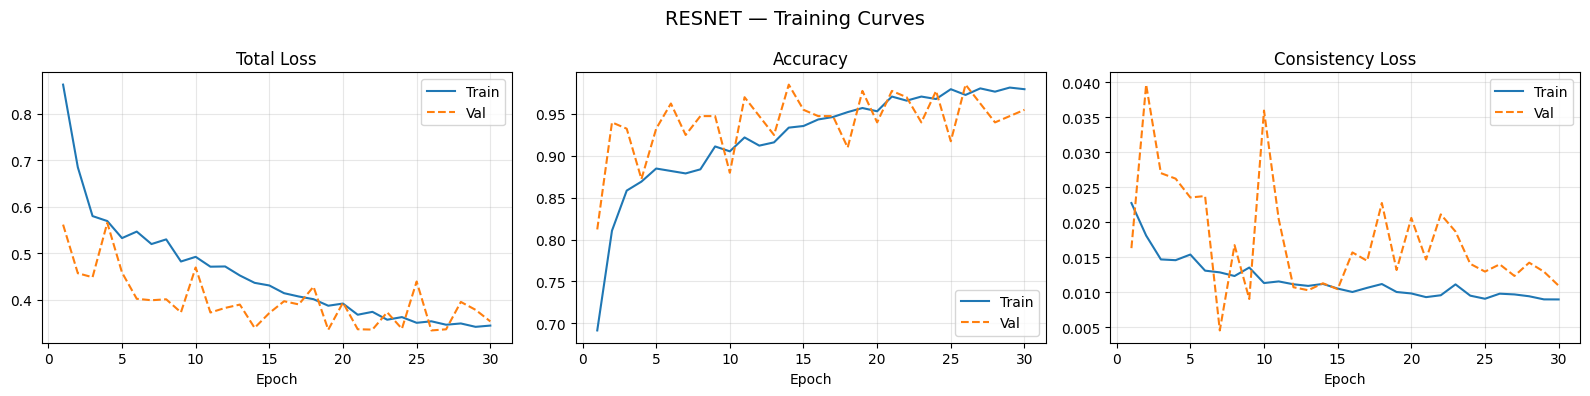

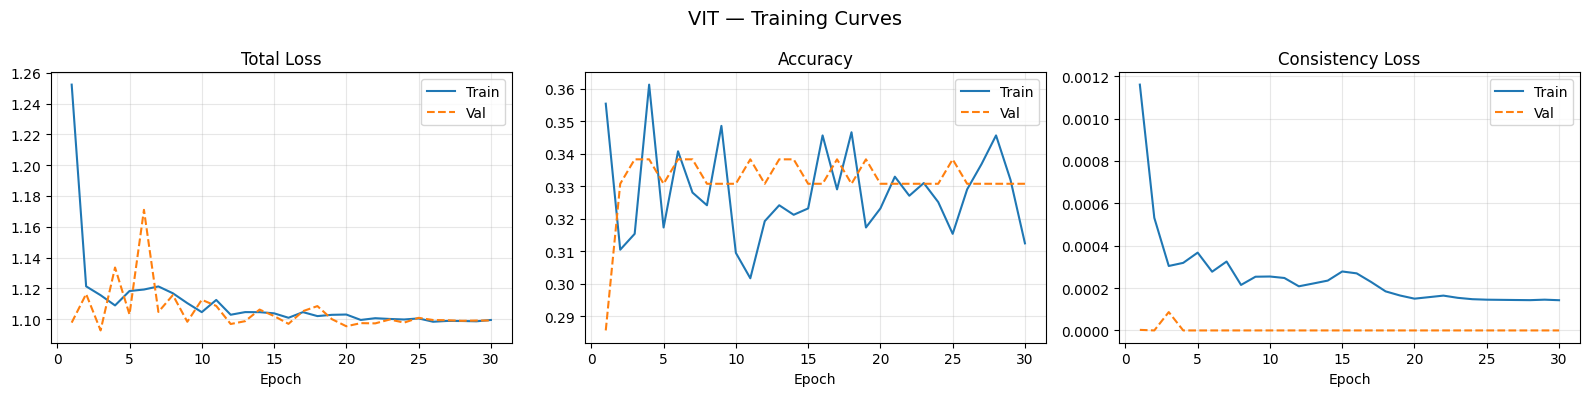

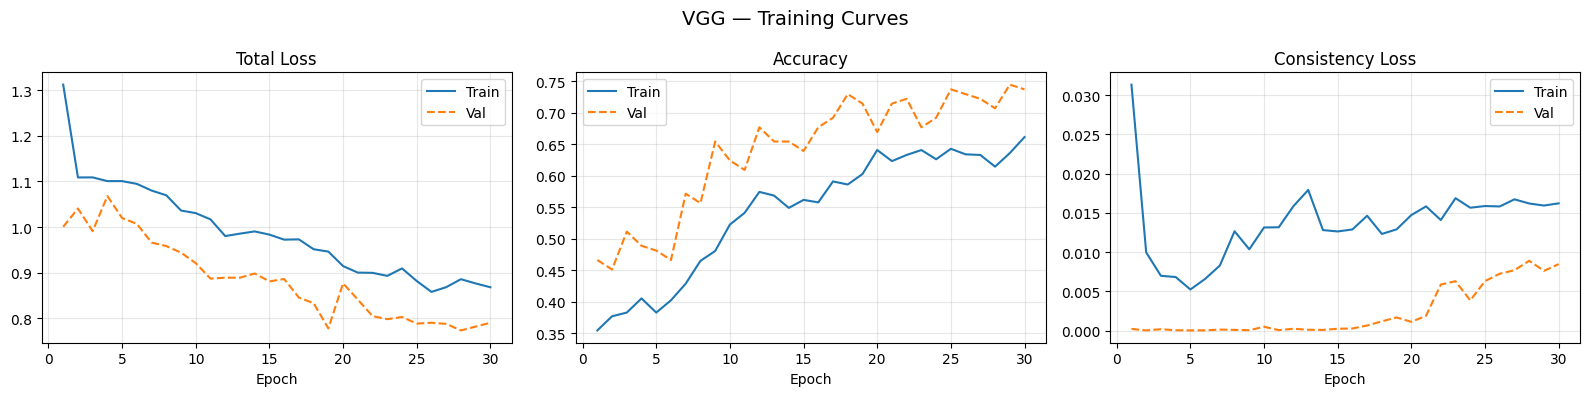

In [16]:
import matplotlib.pyplot as plt

def plot_history(history: dict, arch: str):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"{arch.upper()} — Training Curves", fontsize=14)

    for ax, (metric, label) in zip(axes, [
        ("loss",    "Total Loss"),
        ("acc",     "Accuracy"),
        ("consist", "Consistency Loss"),
    ]):
        ax.plot(epochs, history[f"train_{metric}"], label="Train")
        ax.plot(epochs, history[f"val_{metric}"],   label="Val", linestyle="--")
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"results/curves_{arch}.png", dpi=120)
    plt.show()

for arch, hist in all_histories.items():
    plot_history(hist, arch)

## 8. Evaluate on test set

In [17]:
from evaluator import Evaluator

all_results = {}

for arch in ARCHS_TO_TRAIN:
    model   = build_model(arch).to(device)
    trainer = Trainer(model, loaders, arch_name=arch, device=device)
    trainer.load_best()

    evaluator = Evaluator(arch_name=arch, device=device)
    results   = evaluator.evaluate(
        model       = trainer.model,
        loader      = loaders["test"],
        split_name  = "test",
        class_names = config.CLASSES,
    )
    all_results[arch] = results

Loaded best checkpoint for resnet (epoch 14, val_acc=0.9850)

────────────────────────────────────────────────────────────
  [RESNET]  Evaluation on: test
────────────────────────────────────────────────────────────
   Scale      Acc       F1    Entropy      ECE
    1.00   0.9850   0.9850     0.2938   0.0704
    0.75   0.9774   0.9774     0.2834   0.0659
    0.50   0.9774   0.9774     0.2795   0.0745
    0.25   0.9850   0.9849     0.3534   0.0950

  Prediction Stability Index (PSI) : 0.9699
  Cross-Scale Agreement (sample)   :
    1.00_vs_0.75: 0.9774
    1.00_vs_0.50: 0.9774
    1.00_vs_0.25: 0.9699
    0.75_vs_0.50: 1.0000
    0.75_vs_0.25: 0.9925
    0.50_vs_0.25: 0.9925

  Results saved → results/eval_resnet_test.json
Loaded best checkpoint for vit (epoch 3, val_acc=0.3383)

────────────────────────────────────────────────────────────
  [VIT]  Evaluation on: test
────────────────────────────────────────────────────────────
   Scale      Acc       F1    Entropy      ECE
    1.00   0

## 9. Evaluate on unseen (Mendeley) dataset  *(optional)*

Skip this cell if you don't have the Mendeley dataset.

In [18]:
# ── Section 9: Evaluate on Unseen Mendeley Dataset ──────────────────────────
# SETUP: In Colab, click the folder icon (left sidebar) → Upload
#        Upload "Bean Disease.zip" then run this cell.

import os, shutil, zipfile
from pathlib import Path
from dataset import get_unseen_loader
import config

# ── Step 1: Extract the ZIP ──────────────────────────────────────────────────
ZIP_PATH   = "/content/Bean Disease.zip"   # path after manual upload in Colab
RAW_DIR    = "/content/data/unseen_raw"
UNSEEN_DIR = config.UNSEEN_DIR             # "data/unseen"

if not os.path.exists(RAW_DIR):
    print("Extracting ZIP...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(RAW_DIR)
    print("Done.")

# Preview what folders were extracted
print("\nExtracted folders:")
for p in sorted(Path(RAW_DIR).rglob("*")):
    if p.is_dir():
        print(f"  {p.relative_to(RAW_DIR)}")

Extracting ZIP...
Done.

Extracted folders:
  Bean Disease


In [23]:
# See ALL contents including files
from pathlib import Path

RAW_DIR = "/content/data/unseen_raw"

for p in sorted(Path(RAW_DIR).rglob("*")):
    depth = len(p.relative_to(RAW_DIR).parts)
    indent = "  " * depth
    print(f"{indent}{p.name}  {'[DIR]' if p.is_dir() else ''}")

  Bean Disease  [DIR]
    Angular-Leaf-Spot.zip  
    Bacterial-Pathogen.zip  
    Cercospora-Leaf-Spot.zip  
    Fungi-Pathogens.zip  
    Good-Leaves.zip  
    Halo-Blight.zip  
    No-Disease-Bean.zip  
    Potassium-Deficiency.zip  


In [24]:
# ── Step 2: Extract the two needed class ZIPs and organise ──────────────────
import zipfile, shutil, os
from pathlib import Path

RAW_DIR    = "/content/data/unseen_raw"
UNSEEN_DIR = config.UNSEEN_DIR   # "data/unseen"

# Map: ZIP filename  →  canonical class folder name
CLASS_ZIPS = {
    "Angular-Leaf-Spot.zip": "angular_leaf_spot",
    "Good-Leaves.zip":       "healthy",
}

os.makedirs(UNSEEN_DIR, exist_ok=True)

for zip_name, canonical in CLASS_ZIPS.items():
    zip_path = Path(RAW_DIR) / "Bean Disease" / zip_name
    dst      = Path(UNSEEN_DIR) / canonical

    if dst.exists():
        print(f"[SKIP] {dst} already exists")
        continue

    if not zip_path.exists():
        print(f"[ERROR] Not found: {zip_path}")
        continue

    # Extract to a temp folder, then move all images into dst
    tmp = Path(RAW_DIR) / f"_tmp_{canonical}"
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(tmp)

    dst.mkdir(parents=True, exist_ok=True)
    imgs_copied = 0
    for img in tmp.rglob("*"):
        if img.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
            shutil.copy(str(img), str(dst / img.name))
            imgs_copied += 1

    shutil.rmtree(tmp)
    print(f"[OK] {zip_name}  →  {dst}  ({imgs_copied} images)")

# Verify
print(f"\nReady! Classes in {UNSEEN_DIR}:")
for cls in config.UNSEEN_CLASSES:
    imgs = list((Path(UNSEEN_DIR) / cls).glob("*"))
    print(f"  {cls}: {len(imgs)} images")

[OK] Angular-Leaf-Spot.zip  →  data/unseen/angular_leaf_spot  (270 images)
[OK] Good-Leaves.zip  →  data/unseen/healthy  (1164 images)

Ready! Classes in data/unseen:
  healthy: 1164 images
  angular_leaf_spot: 270 images


In [26]:
# ── Step 3: Evaluate each architecture on the unseen set ────────────────────
from models import build_model
from trainer import Trainer
from evaluator import Evaluator
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

unseen_loader = get_unseen_loader(UNSEEN_DIR)

for arch in ARCHS_TO_TRAIN:
    print(f"\n{'='*60}")
    print(f"  Evaluating [{arch.upper()}] on Mendeley unseen set")
    print(f"{'='*60}")

    model   = build_model(arch).to(device)
    trainer = Trainer(model, loaders, arch_name=arch, device=device)
    trainer.load_best()
    trainer.model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, ms_images, labels in unseen_loader:
            images = images.to(device)
            logits = trainer.model(images)
            preds  = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Only evaluate on the 2 unseen classes (indices 0 and 2)
    # angular_leaf_spot=0, healthy=2
    label_indices = [config.UNSEEN_MAP[c] for c in config.UNSEEN_CLASSES]

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds,
                   labels=label_indices,
                   average="macro", zero_division=0)

    print(f"\n  Accuracy : {acc:.4f}")
    print(f"  Macro F1 : {f1:.4f}")
    print(f"\n  Per-class report:")
    print(classification_report(
        all_labels, all_preds,
        labels      = label_indices,
        target_names= config.UNSEEN_CLASSES,
        zero_division= 0,
    ))

    del model, trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

[test] Loaded 1434 images from 2 classes in 'data/unseen'

  Evaluating [RESNET] on Mendeley unseen set
Loaded best checkpoint for resnet (epoch 14, val_acc=0.9850)

  Accuracy : 0.8117
  Macro F1 : 0.4487

  Per-class report:
                   precision    recall  f1-score   support

          healthy       0.81      1.00      0.90      1164
angular_leaf_spot       0.00      0.00      0.00       270

        micro avg       0.81      0.81      0.81      1434
        macro avg       0.41      0.50      0.45      1434
     weighted avg       0.66      0.81      0.73      1434


  Evaluating [VIT] on Mendeley unseen set
Loaded best checkpoint for vit (epoch 3, val_acc=0.3383)

  Accuracy : 0.8103
  Macro F1 : 0.4476

  Per-class report:
                   precision    recall  f1-score   support

          healthy       0.81      1.00      0.90      1164
angular_leaf_spot       0.00      0.00      0.00       270

         accuracy                           0.81      1434
        macro av

## 10. Summary table

In [27]:
import pandas as pd

rows = []
for arch, res in all_results.items():
    for scale, m in res["per_scale"].items():
        rows.append({
            "arch":     arch,
            "scale":    scale,
            "accuracy": m["accuracy"],
            "macro_f1": m["macro_f1"],
            "entropy":  m["entropy"],
            "ece":      m["ece"],
            "psi":      res["psi"],
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

  arch scale  accuracy  macro_f1  entropy      ece      psi
resnet  1.00  0.984962  0.985016 0.293845 0.070392 0.969925
resnet  0.75  0.977444  0.977441 0.283369 0.065931 0.969925
resnet  0.50  0.977444  0.977441 0.279487 0.074461 0.969925
resnet  0.25  0.984962  0.984930 0.353425 0.095012 0.969925
   vit  1.00  0.338346  0.181481 1.091318 0.057413 0.992481
   vit  0.75  0.338346  0.181481 1.091315 0.057411 0.992481
   vit  0.50  0.330827  0.165725 1.091517 0.056038 0.992481
   vit  0.25  0.330827  0.165725 1.091516 0.056038 0.992481
   vgg  1.00  0.744361  0.747195 0.962480 0.216379 0.676692
   vgg  0.75  0.766917  0.770879 0.961785 0.240579 0.676692
   vgg  0.50  0.691729  0.697646 0.961292 0.170661 0.676692
   vgg  0.25  0.593985  0.591197 0.952530 0.105840 0.676692


## 11. Download results

Run the cell below to download all JSON results and training curves to your local machine.

In [28]:
import shutil
from google.colab import files

shutil.make_archive("results", "zip", "results")
files.download("results.zip")

shutil.make_archive("logs", "zip", "logs")
files.download("logs.zip")

shutil.make_archive("checkpoints", "zip", "checkpoints")
files.download("checkpoints.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>